In [2]:
import json
import torch
import numpy as np
import random
import os
import pandas as pd
import sys
import random
import math
import argparse
import yaml
from pathlib import Path
import datetime
import wandb
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt


In [3]:
def make_unitary(v):
    """
    Makes input unitary (Fourier components have magnitude of 1)
    """
    fv = torch.fft.fft(v.double(), axis=1)
    fv = fv/torch.sqrt(fv.real**2 + fv.imag**2)
    return torch.fft.ifft(fv, axis=1).real.type_as(v)

def make_tensor_unitary(v):
    """
    Makes input tensor unitary (Fourier components have magnitude of 1)
    """
    fv = torch.fft.fft(v, axis=1)
    fv = fv/torch.sqrt(fv.real**2 + fv.imag**2)
    return torch.fft.ifft(fv, axis=1).real

def invert(a, dim):
    """
    Inverts input under binding
    """
    return a[:,-torch.arange(dim, device=a.device)]

def identity(dim):
    """
    Returns
    -------
    torch.tensor
        dim-D identity vector under binding
    """
    s = torch.zeros((1, dim), dtype=torch.float32)
    s[0][0] = 1
    return s

def null(shape):
    """
    Returns
    -------
    torch.tensor
        dim-D null vector under binding
    """
    s = torch.zeros(shape, dtype=torch.float32)
    return s

def bind(a, b):
    """
    Binds together input using torch tensors.

    Parameters
    ----------
    a : torch.Tensor
        A tensor with shape (n_samples x vsa_dim)

    b : torch.Tensor
        A tensor with shape (n_samples x vsa_dim)

    Returns
    -------
    torch.Tensor
        A tensor with shape (n_samples x vsa_dim). Row i is a[i,:] bound with b[i,:]
    """
    ## Ensure the inputs are at least 2D (this behavior mimics np.atleast_2d)
    a = a.unsqueeze(0) if a.dim() == 1 else a
    b = b.unsqueeze(0) if b.dim() == 1 else b
    
    # Compute the FFT of both inputs along the last dimension
    fft_a = torch.fft.fft(a, dim=1)
    fft_b = torch.fft.fft(b, dim=1)

    # Multiply the FFTs element-wise
    fft_product = fft_a * fft_b

    # Perform the inverse FFT
    bound = torch.fft.ifft(fft_product, dim=1)

    return bound

def SampleUniformHypersphere(surface, n, d, rng=torch, min_magnitude=1):
    if d is None or d < 1:
        raise ValueError("Dimensions must be a positive integer", 'd')

    # Generate n x d random samples from a normal distribution
    samples = rng.randn(n, d)
    samples = samples / samples.norm(dim=1, keepdim=True)  # Normalize along the last dimension

    if surface:
        return samples

    # Generate magnitudes for vectors from a uniform distribution.
    # The (1 / d) exponent ensures that samples are uniformly distributed
    # in n-space and not all bunched up at the centre of the sphere.
    samples = samples * (rng.rand(n, 1) * (1 - min_magnitude**d) + min_magnitude**d) ** (1. / d)
    return samples


In [4]:
class SymbolicEngineQuantumVSA():
    def __init__(self, VSA_dim=4096, n_qubits=10, n_states=2,
                 curr_dir=".", seed=4):
        #torch.manual_seed(seed)
        #torch.random.seed = seed

        self.VSA_dim  = VSA_dim
        self.n_qubits = n_qubits
        self.n_states = n_states

        # VSAs needed: n_qubits * n_states

        self.domain_size = self.n_states * self.n_qubits
        self.vectors = make_unitary(SampleUniformHypersphere(surface=True, n=self.domain_size, d=VSA_dim)).to(torch.complex128)
        for j in range(self.domain_size):
            q = self.vectors[j,:]/torch.linalg.norm(self.vectors[j,:])
            for k in range(j+1,self.domain_size):
                self.vectors[k,:] = self.vectors[k,:] - (q @ self.vectors[k,:]) * q
        self.vectors = make_tensor_unitary(self.vectors)
        self.inverse_vectors = invert(self.vectors, VSA_dim)

        self.VSAs         = {}
        self.inverse_VSAs = {}
        c = 0
        for qubit in range(n_qubits):
            self.VSAs[qubit]         = {}
            self.inverse_VSAs[qubit] = {}
            for state in range(n_states):
                self.VSAs        [qubit][state] = self.vectors[c]
                self.inverse_VSAs[qubit][state] = self.inverse_vectors[c]
                c += 1

        self.basis_states         = [] 
        self.basis_state_inverses = [] 
        # Basis states is a list of VSAs, with each entry corresponding to the VSA that represents
        # the index of that entry. For example, the basis_states[13] would be the VSA that
        # represents the qubit configuration 1101 (if n_states = 2 and n_qubits = 4)
        for qubit_state in range(n_states ** n_qubits):
            indices = np.base_repr(qubit_state, n_states).zfill(n_qubits)
            state_vsa = self.VSAs[0][int(indices[0])].unsqueeze(0)
            for i in range(1, n_qubits):
                state_vsa = bind(state_vsa, self.VSAs[int(i)][int(indices[i])])
            self.basis_states         += [       state_vsa                        ]
            self.basis_state_inverses += [invert(state_vsa, VSA_dim)]

        self.basis_states         = torch.stack(self.basis_states        ).squeeze(1).type(torch.complex128)
        self.basis_state_inverses = torch.stack(self.basis_state_inverses).squeeze(1).type(torch.complex128)


In [6]:
def create_vsa_gate_matrix(U, QuantumVSAs):
    if U.shape[0] != U.shape[1]:
        raise ValueError(f"U must be square, got shape {U.shape}")
    n = U.shape[0]
    if n != len(QuantumVSAs.VSAs[0]) ** len(QuantumVSAs.VSAs):
        raise ValueError(f"Number of qubits represented by U must equal the number of qubits in the vsa dictionary")

    s = len(QuantumVSAs.VSAs[0])
    k = n * s
    
    B = QuantumVSAs.basis_states.T   # (D, N)

    # --- Target matrix T = B @ U ---
    T = B @ U  # (D, N)

    # --- Pseudoinverse and final gate matrix ---
    B_pinv = torch.linalg.pinv(B)  # (N, D)
    M = T @ B_pinv                 # (D, D)

    return M.type(torch.complex128).to(B.device)        

def create_vsa_unitary_gate(U, QuantumVSAs):
    # B: (D, N) columns are basis vectors
    B = QuantumVSAs.basis_states.T.to(torch.complex128)  # (D, N)
    U = U.to(torch.complex128)

    # Orthonormal basis for span(B)
    Q, _ = torch.linalg.qr(B, mode="reduced")  # Q: (D, N), Q^H Q = I

    D = Q.shape[0]
    I = torch.eye(D, dtype=Q.dtype, device=Q.device)

    # Unitary extension: G = Q U Q^H + (I - Q Q^H)
    P = Q @ Q.conj().T
    G = Q @ U @ Q.conj().T + (I - P)
    return G


## Measurement Accuracy vs VSA Dimension

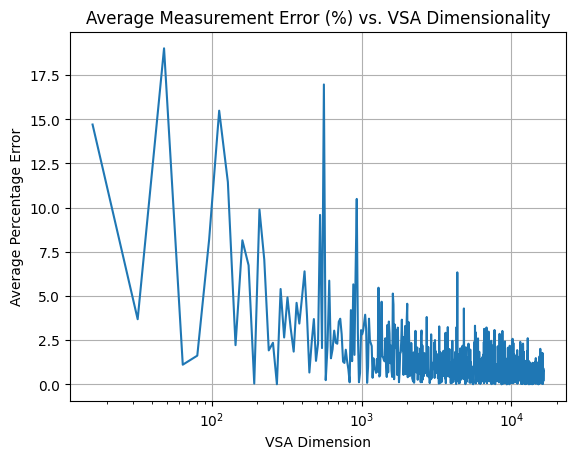

In [4]:
def measurement_accuracy(QuantumVSAs, verbose=False):
    # Create the VSA state corresponding to |phi> = alpha * |0> + beta * |1>
    # Randomly sample alpha and beta as complex numbers in the complex unit disc
    alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
    # Make sure alpha and beta are normalized
    alpha, beta = (alpha / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta),
                   beta  / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta))
    if verbose:
        print("Alpha and Beta after Normalization:", alpha, beta)
    # The first index of QuantumVSAs.VSAs is the qubit number, the second index is the state value
    phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

    # Once we create the state, we can try obtaining the probability of measuring |0> and |1>
    dp0 = (phi * QuantumVSAs.VSAs[0][0]).sum().numpy()
    p0  = dp0.conjugate() * dp0
    dp1 = (phi * QuantumVSAs.VSAs[0][1]).sum().numpy()
    p1  = dp1.conjugate() * dp1

    if verbose:
        print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
        print("Probability of measuring 0 and 1 (actual):", (alpha*alpha.conjugate()).real, (beta*beta.conjugate()).real)
        print("Probability of measuring 0 and 1 (error):", p0.real - (alpha*alpha.conjugate()).real, p1.real - (beta*beta.conjugate()).real)
        print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - (alpha*alpha.conjugate()).real) / (alpha*alpha.conjugate()).real * 100, 
                                                                   abs(p1.real - (beta*beta.conjugate()).real) / (beta*beta.conjugate()).real * 100)
    
    return (abs(p0.real - (alpha*alpha.conjugate()).real) / (alpha*alpha.conjugate()).real * 100 + abs(p1.real - (beta*beta.conjugate()).real) / (beta*beta.conjugate()).real * 100) / 2

n_trials = 1000
average_errors = []
VSA_dims       = np.arange(16, 262144//2**2, 32) # [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
for trial_VSA_dim in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=trial_VSA_dim, n_qubits=1, n_states=2)
    errors = []
    for n in range(n_trials):
        errors += [measurement_accuracy(QuantumVSAs)]

#     print("Average Percentage error:", np.array(errors).mean())
#     plt.hist(errors, bins=100)
#     plt.title("VSA dim: " + str(trial_VSA_dim) + ", average error: " + str(np.array(errors).mean()))
#     plt.xlim((0, 100))
#     plt.show()
    
    average_errors += [np.array(errors).mean()]
    
plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Measurement Error (%) vs. VSA Dimensionality")
plt.grid()
plt.show()

## Gate Application

In [5]:
# VSA_dim = 4096
# n_qubits = 10 # Ten qubit system (We don't need to use all 10 qubits)
# n_states = 2 # Two level system
# verbose = True
# QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states)

# # Randomly sample alpha and beta as complex numbers in the complex unit disc
# alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# alpha, beta  = 1/np.sqrt(2), 1/np.sqrt(2) #np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# print("Alpha and Beta after Normalization:", alpha, beta)
# # Make sure alpha and beta are normalized
# alpha, beta = (alpha / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta),
#                beta  / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta))
# #alpha = 1
# #beta  = 0

# phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

# # In matrix form,
# #  H = 1/sqrt(2) ((1,  1),
# #                 (1, -1))
# # We can measure the impact H has on the basis states |0> and |1> in order to create a VSA equivalent to H:
# #  H|0> = 1/sqrt(2)(|0> + |1>), H|1> = 1/sqrt(2)(|0> - |1>)
# H = 1/np.sqrt(2) * (bind(QuantumVSAs.inverse_VSAs[0][0], (QuantumVSAs.VSAs[0][0] + QuantumVSAs.VSAs[0][1])) +
#                     bind(QuantumVSAs.inverse_VSAs[0][1], (QuantumVSAs.VSAs[0][0] - QuantumVSAs.VSAs[0][1])))

# # When H is applied to |phi> = alpha * |0> + beta * |1>, the resultant state will be:
# #  H(alpha * |0> + beta * |1>) = 1/sqrt(2)(alpha + beta)|0> + (alpha - beta)|1>
# phi_prime = bind(phi, H)

# # Once again, to measure the accuracy of our transformation, we find the probability of measuring |0> and |1> from phi_prime
# #  and compare it to the actual probability of those outcomes

# dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
# p0  = dp0.conjugate() * dp0
# dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
# p1  = dp1.conjugate() * dp1

# if verbose:
#     print("Probability of measuring 0 and 1 (VSA):", p0.real, p1.real)
#     print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
#                                                         1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
#     print("Probability of measuring 0 and 1 (error):", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
#                                                        p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
#     print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
#                                                                abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)


In [11]:
VSA_dim = 2048
n_qubits = 1
n_states = 2
verbose = True
QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=VSA_dim, n_qubits=n_qubits, n_states=n_states)

alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
#alpha, beta  = 1/np.sqrt(2), 1/np.sqrt(2) #np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
# Make sure alpha and beta are normalized
alpha, beta = (alpha / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta),
               beta  / np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta))
print("Alpha and Beta after Normalization:", alpha, beta)

print("VSA Gate:")

phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]

# Apply Hadamard using the coefficient approach
H = 1/np.sqrt(2) * torch.tensor([[1, 1], [1, -1]]).type(torch.complex128)
H = create_vsa_gate_matrix(U=H, QuantumVSAs=QuantumVSAs)
phi_prime = H @ phi

# Measure probabilities
dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
p0 = (dp0.conjugate() * dp0).real
dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
p1 = (dp1.conjugate() * dp1).real

if verbose:
    print("Probability of measuring 0 and 1 (VSA):  ", p0.real, p1.real)
    print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (error): ", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
                                                               abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)
print("Unitary Gate:")
phi = alpha * QuantumVSAs.VSAs[0][0] + beta * QuantumVSAs.VSAs[0][1]
# Apply Hadamard using the coefficient approach
H = 1/np.sqrt(2) * torch.tensor([[1, 1], [1, -1]]).type(torch.complex128)
H = create_vsa_unitary_gate(U=H, QuantumVSAs=QuantumVSAs)
phi_prime = H @ phi

# Measure probabilities
dp0 = (phi_prime * QuantumVSAs.VSAs[0][0]).sum().numpy()
p0 = (dp0.conjugate() * dp0).real
dp1 = (phi_prime * QuantumVSAs.VSAs[0][1]).sum().numpy()
p1 = (dp1.conjugate() * dp1).real

if verbose:
    print("Probability of measuring 0 and 1 (VSA):   ", p0.real, p1.real)
    print("Probability of measuring 0 and 1 (actual):", 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (error): ", p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real, 
                                                        p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real)
    print("Probability of measuring 0 and 1 (percent error):", abs(p0.real - 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real) / 1/2 * ((alpha + beta)*(alpha + beta).conjugate()).real * 100, 
                                                               abs(p1.real - 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real) / 1/2 * ((alpha - beta)*(alpha - beta).conjugate()).real * 100)


Alpha and Beta after Normalization: (0.5829552102101082-0.513305649732284j) (0.018612072387953867+0.6295507315564266j)
VSA Gate:
Probability of measuring 0 and 1 (VSA):   0.18524432124360435 0.8097508073703042
Probability of measuring 0 and 1 (actual): 0.1876980572703591 0.8123019427296407
Probability of measuring 0 and 1 (error):  -0.0024537360267547492 -0.002551135359336487
Probability of measuring 0 and 1 (percent error): 0.04605614852761563 0.2072292208555309
Unitary Gate:
Probability of measuring 0 and 1 (VSA):    0.8211306273999325 0.18944719267910767
Probability of measuring 0 and 1 (actual): 0.1876980572703591 0.8123019427296407
Probability of measuring 0 and 1 (error):  0.6334325701295733 -0.622854750050533
Probability of measuring 0 and 1 (percent error): 11.88940628250914 50.59461235044328


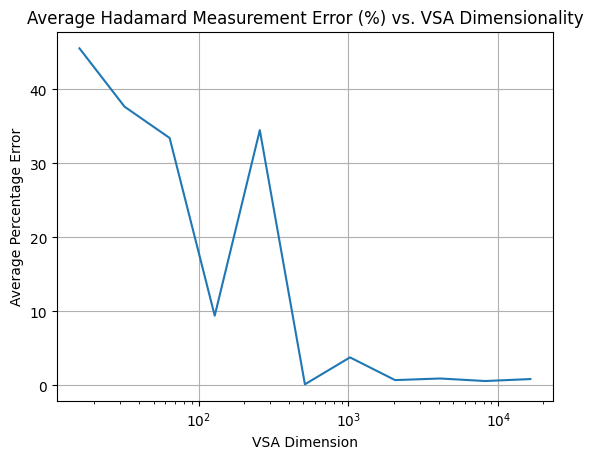

In [21]:
# ------------------------------------------------------------
# Hadamard gate accuracy (like measurement_accuracy but with H)
# ------------------------------------------------------------
def hadamard_accuracy(QuantumVSAs, M_H, verbose=False):
    """
    Sample a random 1-qubit state |phi> = alpha|0> + beta|1>,
    apply the VSA-space Hadamard matrix M_H, and compare the
    resulting measurement probabilities to the exact quantum result.

    Returns:
        average percent error over p(0) and p(1).
    """

    # Sample random complex alpha, beta and normalize
    alpha, beta  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(
        1.j * np.random.uniform(0, 2 * np.pi, 2)
    )
    norm = np.sqrt(alpha.conjugate() * alpha + beta.conjugate() * beta)
    alpha /= norm
    beta  /= norm

    if verbose:
        print("Alpha and Beta after normalization:", alpha, beta)

    v0 = QuantumVSAs.VSAs[0][0]
    v1 = QuantumVSAs.VSAs[0][1]

    # Encode |phi> in VSA space
    phi = alpha * v0 + beta * v1

    # Apply VSA-space Hadamard
    phi_prime = M_H @ phi

    # VSA-measured probabilities
    dp0 = (phi_prime * v0).sum().numpy()
    p0  = (dp0.conjugate() * dp0).real
    dp1 = (phi_prime * v1).sum().numpy()
    p1  = (dp1.conjugate() * dp1).real

    # Exact quantum probabilities after H:
    # |phi'> = H|phi> = (alpha+beta)/sqrt(2)|0> + (alpha-beta)/sqrt(2)|1>
    p0_true = 0.5 * ((alpha + beta) * (alpha + beta).conjugate()).real
    p1_true = 0.5 * ((alpha - beta) * (alpha - beta).conjugate()).real

    err0 = abs(p0 - p0_true) / p0_true * 100.0
    err1 = abs(p1 - p1_true) / p1_true * 100.0

    if verbose:
        print("VSA probs:", p0, p1)
        print("True probs:", p0_true, p1_true)
        print("Percent errors:", err0, err1)

    return (err0 + err1) / 2.0


# ------------------------------------------------------------
# Accuracy vs VSA dimension loop (analogous to measurement_accuracy loop)
# ------------------------------------------------------------
n_trials = 100
average_errors = []
#VSA_dims       = np.arange(16, 2048 + 1, 16)
VSA_dims       = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384] # np.arange(16, 262144//2**4, 16)

for trial_VSA_dim in VSA_dims:
    # One-qubit, 2-state system
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=trial_VSA_dim, n_qubits=1, n_states=2
    )

    # Define 1-qubit Hadamard in computational basis
    H = (1.0 / np.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=torch.complex128,
        device=QuantumVSAs.VSAs[0][0].device
    )

    # Build VSA-space Hadamard matrix once per VSA_dim
    M_H = create_vsa_gate_matrix(U=H, QuantumVSAs=QuantumVSAs)

    errors = []
    for _ in range(n_trials):
        errors.append(hadamard_accuracy(QuantumVSAs, M_H, verbose=False))

    avg_err = np.mean(errors)
    average_errors.append(avg_err)
    #print(f"VSA_dim={trial_VSA_dim}, avg % error={avg_err:.4f}")

# Plot
plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Hadamard Measurement Error (%) vs. VSA Dimensionality")
plt.grid(True)
plt.show()


## Quantum Teleportation

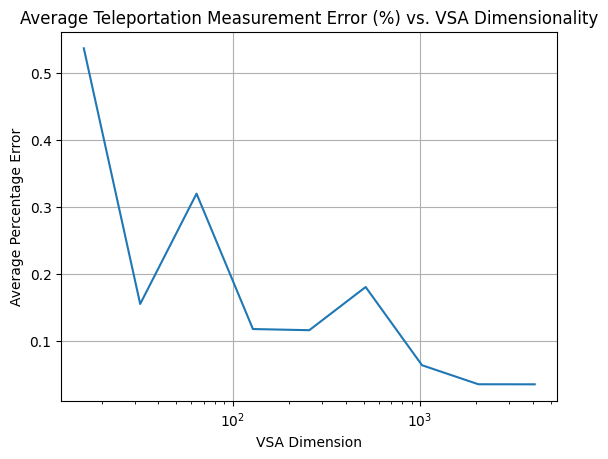

In [22]:
# ---------- Build teleportation gates in VSA space ----------
def build_teleportation_gates(QuantumVSAs):
    """
    Build 3-qubit VSA-space gate matrices for:
      - CNOT(0→1)
      - H on qubit 0
      - X on qubit 2
      - Z on qubit 2

    All returned matrices have shape (D, D) and act on column vectors.
    """
    device = QuantumVSAs.VSAs[0][0].device
    dtype  = torch.complex128

    I2 = torch.eye(2, dtype=dtype, device=device)

    H = (1.0 / math.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=dtype,
        device=device,
    )

    X = torch.tensor([[0, 1],
                      [1, 0]], dtype=dtype, device=device)

    Z = torch.tensor([[1,  0],
                      [0, -1]], dtype=dtype, device=device)

    # 2-qubit CNOT with control=q0 (MSB), target=q1 (second bit)
    # basis ordering: |00>, |01>, |10>, |11> with index = a*2 + b
    C = torch.zeros((4, 4), dtype=dtype, device=device)
    for a in (0, 1):   # control
        for b in (0, 1):  # target
            in_idx = a * 2 + b
            out_b  = b ^ a      # flip target iff control==1
            out_idx = a * 2 + out_b
            C[out_idx, in_idx] = 1.0

    # 3-qubit unitaries
    U_CNOT01 = torch.kron(C, I2)                        # CNOT(0→1) on (q0,q1)
    U_H0     = torch.kron(H, torch.kron(I2, I2))        # H ⊗ I ⊗ I
    U_X2     = torch.kron(torch.kron(I2, I2), X)        # I ⊗ I ⊗ X
    U_Z2     = torch.kron(torch.kron(I2, I2), Z)        # I ⊗ I ⊗ Z

    M_CNOT01 = create_vsa_gate_matrix(U_CNOT01, QuantumVSAs)
    M_H0     = create_vsa_gate_matrix(U_H0,     QuantumVSAs)
    M_X2     = create_vsa_gate_matrix(U_X2,     QuantumVSAs)
    M_Z2     = create_vsa_gate_matrix(U_Z2,     QuantumVSAs)

    return M_CNOT01, M_H0, M_X2, M_Z2

def teleportation_trial_abs_error(QuantumVSAs, alpha, beta, verbose=False):
    if verbose:
        print("State:", alpha, beta)
    s = len(QuantumVSAs.VSAs[0])

    # prepare initial state: |ψ>_0 ⊗ (|00> + |11>)/√2
    phi0 = (
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("000", s)] +
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("011", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("100", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("111", s)]
    )

    # 3) apply CNOT(0→1) then H on qubit 0
    M_CNOT01, M_H0, M_X2, M_Z2 = build_teleportation_gates(QuantumVSAs)
    phi1 = M_CNOT01 @ phi0
    phi2 = M_H0 @ phi1
    coeffs = []
    for idx in range(8):
        c = (phi2 * QuantumVSAs.basis_states[idx]).sum().cpu().numpy()
        coeffs.append(c)

    #print([(bin(n)[2:].zfill(3), (c*c.conjugate()).real) for n, c in enumerate(coeffs)])

    results = {}
    for a in (0, 1):
        for b in (0, 1):
            i0 = int(str(a) + str(b) + "0", s)
            i1 = int(str(a) + str(b) + "1", s)

            c0 = coeffs[i0]
            c1 = coeffs[i1]

            prob = (c0.conjugate()*c0 + c1.conjugate()*c1).real

            if prob < 1e-10:
                results[(a, b)] = {"prob": prob, "abs_err": None}
                continue

            # post-measurement branch state
            norm_branch = math.sqrt(prob)
            phi_post = (c0/norm_branch)*QuantumVSAs.basis_states[i0] + (c1/norm_branch)*QuantumVSAs.basis_states[i1]

            # apply corrections X^b Z^a on Bob's qubit (q2)
            phi_corr = phi_post.type(torch.complex128)
            if b == 1:
                phi_corr = M_X2 @ phi_corr
            if a == 1:
                phi_corr = M_Z2 @ phi_corr

            # decode Bob's local state amplitudes in this branch
            d0 = (phi_corr * QuantumVSAs.basis_states[i0]).sum().cpu().numpy()
            d1 = (phi_corr * QuantumVSAs.basis_states[i1]).sum().cpu().numpy()

            norm_bob = math.sqrt((d0.conjugate()*d0 + d1.conjugate()*d1).real)
            d0 /= norm_bob
            d1 /= norm_bob

            p0_vsa = (d0.conjugate()*d0).real
            p1_vsa = (d1.conjugate()*d1).real

            p0_true = (alpha.conjugate()*alpha).real
            p1_true = (beta.conjugate()*beta).real

            abs_err = float(abs(p0_vsa - p0_true) + abs(p1_vsa - p1_true))

            results[(a, b)] = {
                "prob": prob,
                "p_vsa": (float(p0_vsa), float(p1_vsa)),
                "p_true": (float(p0_true), float(p1_true)),
                "abs_err": abs_err,
            }

    return results

def run_simple_teleportation_tests(VSA_dim=2048, n_qubits=3, n_states=2):
    
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=VSA_dim, n_qubits=3, n_states=2
    )

    tests = [
        ("|0⟩", 1+0j, 0+0j),
        ("|1⟩", 0+0j, 1+0j),
        ("|+⟩", 1/math.sqrt(2)+0j, 1/math.sqrt(2)+0j),
        ("|phi⟩", 23+12j, 42+32j),
    ]

    for name, a, b in tests:
        print(f"\n=== Teleportation test for {name} ===")
        res = teleportation_trial_abs_error(QuantumVSAs, a, b, verbose=False)
        for (ab), info in res.items():
            print(f"Outcome (a,b)={ab}:")
            print(f"  branch prob ≈ {info['prob']:.4f}")
            if info["abs_err"] is None:
                print("  (negligible branch)")
                continue
            p0_vsa, p1_vsa = info["p_vsa"]
            p0_true, p1_true = info["p_true"]
            print(f"  Bob p_vsa  ≈ ({p0_vsa:.4f}, {p1_vsa:.4f})")
            print(f"  Bob p_true ≈ ({p0_true:.4f}, {p1_true:.4f})")
            print(f"  abs_err    ≈ {info['abs_err']:.4e}")


#run_simple_teleportation_tests()

verbose = False

n_trials = 1000
average_errors = []
VSA_dims = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096] #np.arange(16, 262144//2**4, 16)

for trial_VSA_dim in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(
        VSA_dim=trial_VSA_dim, n_qubits=3, n_states=2
    )
    
    errors = []
    for _ in range(n_trials):
        a, b  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
        norm = np.sqrt((a.conjugate()*a + b.conjugate()*b).real)
        a /= norm
        b /= norm

        results = teleportation_trial_abs_error(QuantumVSAs, a, b, verbose=verbose)
        
        # probability-weighted error over non-negligible branches
        num = 0.0
        den = 0.0
        for ab, info in results.items():
            p = info["prob"]
            if info["abs_err"] is None:
                continue
            num += p * info["abs_err"]
            den += p

        err = num / max(den, 1e-12)
        errors.append(err)
    avg_err = np.mean(errors)
    average_errors.append(avg_err)
    if verbose:
        print(f"VSA_dim={trial_VSA_dim}, avg % error={avg_err:.4f}")

plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Average Percentage Error")
plt.title("Average Teleportation Measurement Error (%) vs. VSA Dimensionality")
plt.grid(True)
plt.show()


VSA_dim=16, avg error=0.609484
VSA_dim=32, avg error=0.316948
VSA_dim=64, avg error=0.384588
VSA_dim=128, avg error=0.170049
VSA_dim=256, avg error=0.089378
VSA_dim=512, avg error=0.076388
VSA_dim=1024, avg error=0.040145
VSA_dim=2048, avg error=0.037145
VSA_dim=4096, avg error=0.052773


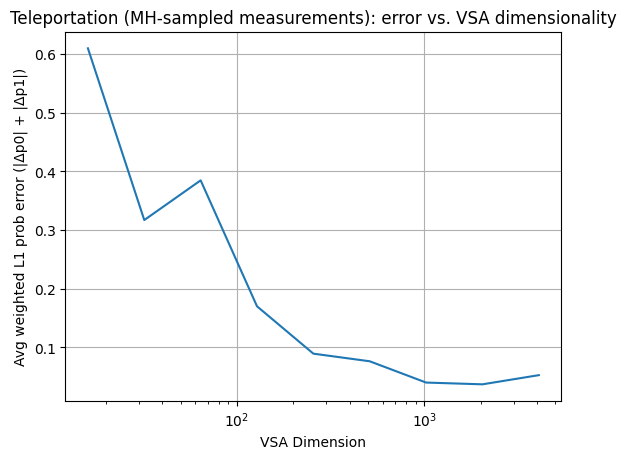

In [7]:
# ---------- Complex inner product helper ----------
def amp(phi, basis_vec):
    """
    Return <basis_vec | phi> as a complex scalar (torch.complex128).
    Uses conjugate inner product.
    """
    return torch.vdot(basis_vec.to(torch.complex128), phi.to(torch.complex128))


# ---------- Build teleportation gates in VSA space ----------
def build_teleportation_gates(QuantumVSAs):
    device = QuantumVSAs.VSAs[0][0].device
    dtype  = torch.complex128

    I2 = torch.eye(2, dtype=dtype, device=device)

    H = (1.0 / math.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=dtype,
        device=device,
    )

    X = torch.tensor([[0, 1],
                      [1, 0]], dtype=dtype, device=device)

    Z = torch.tensor([[1,  0],
                      [0, -1]], dtype=dtype, device=device)

    # 2-qubit CNOT with control=q0 (MSB), target=q1 (second bit)
    C = torch.zeros((4, 4), dtype=dtype, device=device)
    for a in (0, 1):
        for b in (0, 1):
            in_idx = a * 2 + b
            out_b  = b ^ a
            out_idx = a * 2 + out_b
            C[out_idx, in_idx] = 1.0

    # 3-qubit unitaries
    U_CNOT01 = torch.kron(C, I2)
    U_H0     = torch.kron(H, torch.kron(I2, I2))
    U_X2     = torch.kron(torch.kron(I2, I2), X)
    U_Z2     = torch.kron(torch.kron(I2, I2), Z)

    # Compile to VSA-space DxD gates once
    M_CNOT01 = create_vsa_gate_matrix(U_CNOT01, QuantumVSAs)
    M_H0     = create_vsa_gate_matrix(U_H0,     QuantumVSAs)
    M_X2     = create_vsa_gate_matrix(U_X2,     QuantumVSAs)
    M_Z2     = create_vsa_gate_matrix(U_Z2,     QuantumVSAs)

    return M_CNOT01, M_H0, M_X2, M_Z2


# ---------- MH sampler over (a,b) outcomes ----------
def ab_prob_from_phi(phi2, QuantumVSAs, a_bit, b_bit):
    """
    Unnormalized Born probability for measuring (a,b) on first two qubits:
      P(a,b) ∝ |<ab0|phi>|^2 + |<ab1|phi>|^2
    Only 2 inner products, no enumeration over all 8.
    """
    s = len(QuantumVSAs.VSAs[0])
    i0 = int(f"{a_bit}{b_bit}0", s)
    i1 = int(f"{a_bit}{b_bit}1", s)

    c0 = amp(phi2, QuantumVSAs.basis_states[i0])
    c1 = amp(phi2, QuantumVSAs.basis_states[i1])

    p = (c0.conj()*c0 + c1.conj()*c1).real
    return float(p.item()), c0, c1, i0, i1


def mh_sample_ab(phi2, QuantumVSAs, n_samples=2000, burn_in=200, thin=1, xi=1e-18, seed=None):
    """
    Metropolis-Hastings chain on the discrete state space {(a,b)} with 4 states.
    Proposal: flip one of the two bits.
    Target (unnormalized): P(a,b) = |<ab0|phi>|^2 + |<ab1|phi>|^2.
    Returns: list of sampled (a,b).
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    # encode (a,b) as idx in {0..3}: idx = 2*a + b
    cur = int(rng.integers(0, 4))

    def idx_to_ab(idx):
        a = (idx >> 1) & 1
        b = idx & 1
        return a, b

    # cache current prob
    a_cur, b_cur = idx_to_ab(cur)
    p_cur, _, _, _, _ = ab_prob_from_phi(phi2, QuantumVSAs, a_cur, b_cur)
    p_cur = max(p_cur, xi)

    samples = []
    total_steps = burn_in + n_samples * thin

    for t in range(total_steps):
        # propose flip bit 0 (b) or bit 1 (a)
        flip = int(rng.integers(0, 2))
        prop = cur ^ (1 << flip)

        a_p, b_p = idx_to_ab(prop)
        p_prop, _, _, _, _ = ab_prob_from_phi(phi2, QuantumVSAs, a_p, b_p)
        p_prop = max(p_prop, xi)

        # MH accept
        alpha = min(1.0, p_prop / p_cur)
        if rng.random() < alpha:
            cur = prop
            p_cur = p_prop

        # record after burn-in with thinning
        if t >= burn_in and ((t - burn_in) % thin == 0):
            a_s, b_s = idx_to_ab(cur)
            samples.append((a_s, b_s))

    return samples


# ---------- Teleportation using sampled measurements ----------
def teleportation_trial_abs_error_mh(
    QuantumVSAs, alpha, beta,
    n_meas_samples=2000, burn_in=200, thin=1,
    verbose=False, seed=None
):
    """
    Runs teleportation up to measurement-prep, then:
      - samples (a,b) outcomes via MH (no full coeff enumeration),
      - collapses branch using just the two amplitudes for |ab0>,|ab1>,
      - applies corrections,
      - samples Bob's final measurement (0/1) from the branch.

    Returns estimated:
      - branch probs P_hat(a,b)
      - Bob probs conditioned on (a,b): P_hat(bob=0|a,b), P_hat(bob=1|a,b)
      - and the same abs_err metric you used (prob-weighted across branches).
    """
    device = QuantumVSAs.basis_states.device
    dtype  = torch.complex128
    s = len(QuantumVSAs.VSAs[0])

    # prepare initial state: |ψ>_0 ⊗ (|00> + |11>)/√2
    phi0 = (
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("000", s)] +
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("011", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("100", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("111", s)]
    ).to(dtype)

    # apply CNOT(0→1) then H on qubit 0
    M_CNOT01, M_H0, M_X2, M_Z2 = build_teleportation_gates(QuantumVSAs)
    phi1 = (M_CNOT01 @ phi0).to(dtype)
    phi2 = (M_H0     @ phi1).to(dtype)

    # --- SAMPLE partial measurement outcomes (a,b) using MH ---
    ab_samples = mh_sample_ab(
        phi2, QuantumVSAs,
        n_samples=n_meas_samples,
        burn_in=burn_in,
        thin=thin,
        seed=seed
    )

    # Tallies
    count_ab = {(0,0): 0, (0,1): 0, (1,0): 0, (1,1): 0}
    count_bob = {(0,0): [0,0], (0,1): [0,0], (1,0): [0,0], (1,1): [0,0]}  # [count0, count1]

    rng = np.random.default_rng(seed)

    # For each sampled (a,b), do branch collapse, correction, then sample Bob bit
    for (a_bit, b_bit) in ab_samples:
        count_ab[(a_bit, b_bit)] += 1

        # compute branch amplitudes only for |ab0>, |ab1>
        prob, c0, c1, i0, i1 = ab_prob_from_phi(phi2, QuantumVSAs, a_bit, b_bit)
        if prob < 1e-30:
            # effectively never happens if MH is sampling from this distribution,
            # but keep for redundancy.
            continue

        # collapse to post-measurement branch state (still superposition over Bob's qubit)
        norm_branch = math.sqrt(prob)
        phi_post = (c0/norm_branch)*QuantumVSAs.basis_states[i0].to(dtype) + (c1/norm_branch)*QuantumVSAs.basis_states[i1].to(dtype)

        # apply corrections X^b Z^a on Bob's qubit (q2)
        phi_corr = phi_post
        if b_bit == 1:
            phi_corr = M_X2 @ phi_corr
        if a_bit == 1:
            phi_corr = M_Z2 @ phi_corr
        phi_corr = phi_corr.to(dtype)

        # final measurement on Bob: only |ab0>,|ab1> have support
        d0 = amp(phi_corr, QuantumVSAs.basis_states[i0])
        d1 = amp(phi_corr, QuantumVSAs.basis_states[i1])
        denom = float(((d0.conj()*d0 + d1.conj()*d1).real).item())
        if denom < 1e-30:
            continue

        p0 = float(((d0.conj()*d0).real).item()) / denom
        # sample bob bit
        bob_bit = 0 if rng.random() < p0 else 1
        count_bob[(a_bit, b_bit)][bob_bit] += 1

    # Convert tallies to probabilities + error metric (same style as your original)
    total = max(1, len(ab_samples))
    results = {}

    p0_true = float((alpha.conj()*alpha).real)
    p1_true = float((beta.conj()*beta).real)

    for (a_bit, b_bit), cab in count_ab.items():
        p_branch_hat = cab / total

        cb0, cb1 = count_bob[(a_bit,b_bit)]
        if cb0 + cb1 == 0:
            results[(a_bit,b_bit)] = {"prob": p_branch_hat, "abs_err": None}
            continue

        p0_hat = cb0 / (cb0 + cb1)
        p1_hat = cb1 / (cb0 + cb1)

        abs_err = float(abs(p0_hat - p0_true) + abs(p1_hat - p1_true))

        results[(a_bit,b_bit)] = {
            "prob": p_branch_hat,
            "p_vsa": (float(p0_hat), float(p1_hat)),
            "p_true": (p0_true, p1_true),
            "abs_err": abs_err,
        }

    return results


# ---------- Sweep ----------
verbose = True

n_trials = 10
VSA_dims = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
average_errors = []

# MH settings: increase n_meas_samples to reduce Monte Carlo noise
n_meas_samples = 1000
burn_in = 200
thin = 1

for trial_VSA_dim in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=trial_VSA_dim, n_qubits=3, n_states=2)

    errors = []
    for _ in range(n_trials):
        a, b  = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2 * np.pi, 2))
        norm = np.sqrt((a.conjugate()*a + b.conjugate()*b).real)
        a /= norm
        b /= norm

        results = teleportation_trial_abs_error_mh(
            QuantumVSAs, a, b,
            n_meas_samples=n_meas_samples,
            burn_in=burn_in,
            thin=thin,
            verbose=verbose
        )

        # probability-weighted error over non-empty branches (using estimated branch probs)
        num = 0.0
        den = 0.0
        for info in results.values():
            p = info["prob"]
            if info["abs_err"] is None:
                continue
            num += p * info["abs_err"]
            den += p

        err = num / max(den, 1e-12)
        errors.append(err)

    avg_err = float(np.mean(errors))
    average_errors.append(avg_err)
    if verbose:
        print(f"VSA_dim={trial_VSA_dim}, avg error={avg_err:.6f}")

plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Avg weighted L1 prob error (|Δp0| + |Δp1|)")
plt.title("Teleportation (MH-sampled measurements): error vs. VSA dimensionality")
plt.grid(True)
plt.show()


16 8.251012655055096
32 4.873104325101751
64 2.451175815629875
128 1.8960076709515181
256 1.7231794498108166
512 1.2914419857880786
1024 1.2793069307710716
2048 1.1642546235271363
4096 1.0719232518799835


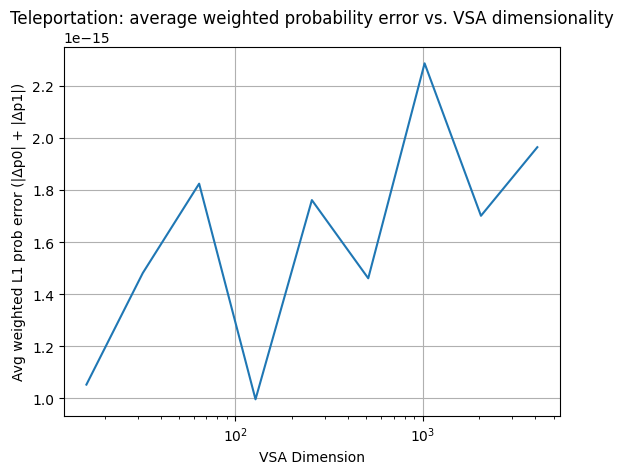

In [14]:
# ---------- Build teleportation gates in VSA space ----------
def build_teleportation_gates(QuantumVSAs):
    """
    Build 3-qubit VSA-space gate matrices for:
      - CNOT(0→1)
      - H on qubit 0
      - X on qubit 2
      - Z on qubit 2

    All returned matrices have shape (D, D) and act on column vectors.
    """
    device = QuantumVSAs.VSAs[0][0].device
    dtype  = torch.complex128

    I2 = torch.eye(2, dtype=dtype, device=device)

    H = (1.0 / math.sqrt(2.0)) * torch.tensor(
        [[1,  1],
         [1, -1]],
        dtype=dtype,
        device=device,
    )

    X = torch.tensor([[0, 1],
                      [1, 0]], dtype=dtype, device=device)

    Z = torch.tensor([[1,  0],
                      [0, -1]], dtype=dtype, device=device)

    # 2-qubit CNOT with control=q0 (MSB), target=q1 (second bit)
    # basis ordering: |00>, |01>, |10>, |11> with index = a*2 + b
    C = torch.zeros((4, 4), dtype=dtype, device=device)
    for a in (0, 1):   # control
        for b in (0, 1):  # target
            in_idx = a * 2 + b
            out_b  = b ^ a
            out_idx = a * 2 + out_b
            C[out_idx, in_idx] = 1.0

    # 3-qubit unitaries
    U_CNOT01 = torch.kron(C, I2)                        # CNOT(0→1) on (q0,q1)
    U_H0     = torch.kron(H, torch.kron(I2, I2))        # H ⊗ I ⊗ I
    U_X2     = torch.kron(torch.kron(I2, I2), X)        # I ⊗ I ⊗ X
    U_Z2     = torch.kron(torch.kron(I2, I2), Z)        # I ⊗ I ⊗ Z

    # Semantic VSA gate construction (your method)
    M_CNOT01 = create_vsa_gate_matrix(U_CNOT01, QuantumVSAs)
    M_H0     = create_vsa_gate_matrix(U_H0,     QuantumVSAs)
    M_X2     = create_vsa_gate_matrix(U_X2,     QuantumVSAs)
    M_Z2     = create_vsa_gate_matrix(U_Z2,     QuantumVSAs)

    return M_CNOT01, M_H0, M_X2, M_Z2


# ---------- Cache helpers: dual-basis decoding (critical) ----------
def prepare_vsa_decode_cache(QuantumVSAs):
    """
    Precompute B and B^+ for decoding *true coefficients* a from phi:
      phi = B a  =>  a = B^+ phi

    Stores:
      QuantumVSAs._B      : (D, N) complex128
      QuantumVSAs._B_pinv : (N, D) complex128
      QuantumVSAs._N      : int
    """
    B = QuantumVSAs.basis_states.T.to(torch.complex128)  # (D, N)
    B_pinv = torch.linalg.pinv(B)                       # (N, D)

    QuantumVSAs._B = B
    QuantumVSAs._B_pinv = B_pinv
    QuantumVSAs._N = B.shape[1]

def prepare_vsa_decode_cache_gram(QuantumVSAs):
    B = QuantumVSAs.basis_states.T.to(torch.complex128)     # (D,N)
    G = B.conj().T @ B                                      # (N,N)
    # Solve G X = B^H  => X = G^{-1} B^H  (this is B^+)
    B_pinv = torch.linalg.solve(G, B.conj().T)              # (N,D)

    QuantumVSAs._B = B.to(torch.complex128)
    QuantumVSAs._B_pinv = B_pinv.to(torch.complex128)
    QuantumVSAs._N = B.shape[1]

def decode_coeffs(QuantumVSAs, phi):
    # returns a of shape (N,)
    return QuantumVSAs._B_pinv @ phi.to(torch.complex128)


def encode_coeffs(QuantumVSAs, a):
    # returns phi of shape (D,)
    return QuantumVSAs._B @ a.to(torch.complex128)


def get_teleportation_gates_cached(QuantumVSAs):
    if not hasattr(QuantumVSAs, "_teleportation_gates"):
        QuantumVSAs._teleportation_gates = build_teleportation_gates(QuantumVSAs)
    return QuantumVSAs._teleportation_gates


    
# ---------- Teleportation trial ----------
def teleportation_trial_abs_error(QuantumVSAs, alpha, beta, verbose=False):
    """
    Returns per-(a,b) branch:
      - prob
      - Bob p_vsa (decoded via B^+)
      - Bob p_true
      - abs_err = |p0_vsa - p0_true| + |p1_vsa - p1_true|
    """
    if verbose:
        print("State:", alpha, beta)

    device = QuantumVSAs.basis_states.device
    dtype = torch.complex128
    s = len(QuantumVSAs.VSAs[0])  # local dimension, for indices base

    # --- Prepare initial state: |ψ>_0 ⊗ (|00> + |11>)/√2 ---
    # basis order: |q0 q1 q2> with base-s index
    phi0 = (
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("000", s)] +
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("011", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("100", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("111", s)]
    ).to(dtype)

    # --- Apply CNOT(0→1) then H on qubit 0 ---
    M_CNOT01, M_H0, M_X2, M_Z2 = get_teleportation_gates_cached(QuantumVSAs)
    phi1 = M_CNOT01 @ phi0
    phi2 = M_H0 @ phi1

    # --- Decode true coefficients a via dual basis ---
    a_pre = decode_coeffs(QuantumVSAs, phi2)  # shape (8,)

    results = {}
    for a_bit in (0, 1):
        for b_bit in (0, 1):
            i0 = int(f"{a_bit}{b_bit}0", s)
            i1 = int(f"{a_bit}{b_bit}1", s)

            c0 = a_pre[i0]
            c1 = a_pre[i1]

            prob = float(((c0.conj()*c0 + c1.conj()*c1).real).item())

            if prob < 1e-12:
                results[(a_bit, b_bit)] = {"prob": prob, "abs_err": None}
                continue

            # --- Post-measurement branch coefficients (only i0,i1 survive), normalized ---
            norm_branch = math.sqrt(prob)
            a_post = torch.zeros_like(a_pre)
            a_post[i0] = c0 / norm_branch
            a_post[i1] = c1 / norm_branch

            # Encode branch state back to VSA space 
            phi_post = encode_coeffs(QuantumVSAs, a_post)

            # --- Apply corrections X^b Z^a on Bob's qubit (q2) ---
            phi_corr = phi_post
            if b_bit == 1:
                phi_corr = M_X2 @ phi_corr
            if a_bit == 1:
                phi_corr = M_Z2 @ phi_corr

            # --- Decode corrected coefficients and extract Bob's local amplitudes ---
            a_corr = decode_coeffs(QuantumVSAs, phi_corr)

            d0 = a_corr[i0]
            d1 = a_corr[i1]

            norm_bob = math.sqrt(float(((d0.conj()*d0 + d1.conj()*d1).real).item()))
            d0 /= norm_bob
            d1 /= norm_bob

            p0_vsa = float((d0.conj()*d0).real.item())
            p1_vsa = float((d1.conj()*d1).real.item())

            p0_true = float((alpha.conj()*alpha).real)
            p1_true = float((beta.conj()*beta).real)

            abs_err = float(abs(p0_vsa - p0_true) + abs(p1_vsa - p1_true))

            results[(a_bit, b_bit)] = {
                "prob": prob,
                "p_vsa": (p0_vsa, p1_vsa),
                "p_true": (p0_true, p1_true),
                "abs_err": abs_err,
            }

    return results

# ---------- Sweep: VSA_dim vs teleportation error ----------
verbose = False

n_trials = 100
average_errors = []
VSA_dims = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

for trial_VSA_dim in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=trial_VSA_dim, n_qubits=3, n_states=2)
    G = (QuantumVSAs.basis_states.T.to(torch.complex128).conj().T
         @ QuantumVSAs.basis_states.T.to(torch.complex128))
    sv = torch.linalg.svdvals(G)
    cond = (sv.max() / sv.min()).item()
    print(trial_VSA_dim, cond)


    # caches (do once per VSA_dim)
    prepare_vsa_decode_cache_gram(QuantumVSAs)
    _ = get_teleportation_gates_cached(QuantumVSAs)

    trial_errs = []
    for _ in range(n_trials):
        a, b = np.sqrt(np.random.uniform(0, 1, 2)) * np.exp(1.j * np.random.uniform(0, 2*np.pi, 2))
        norm = np.sqrt((a.conjugate()*a + b.conjugate()*b).real)
        a /= norm
        b /= norm

        results = teleportation_trial_abs_error(QuantumVSAs, a, b, verbose=verbose)

        # probability-weighted error over non-negligible branches
        num = 0.0
        den = 0.0
        for ab, info in results.items():
            p = info["prob"]
            if info["abs_err"] is None:
                continue
            num += p * info["abs_err"]
            den += p

        err = num / max(den, 1e-12)
        trial_errs.append(err)

    avg_err = float(np.mean(trial_errs))
    average_errors.append(avg_err)

    if verbose:
        print(f"VSA_dim={trial_VSA_dim}, avg weighted abs_err={avg_err:.6f}")

plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Avg weighted L1 prob error (|Δp0| + |Δp1|)")
plt.title("Teleportation: average weighted probability error vs. VSA dimensionality")
plt.grid(True)
plt.show()


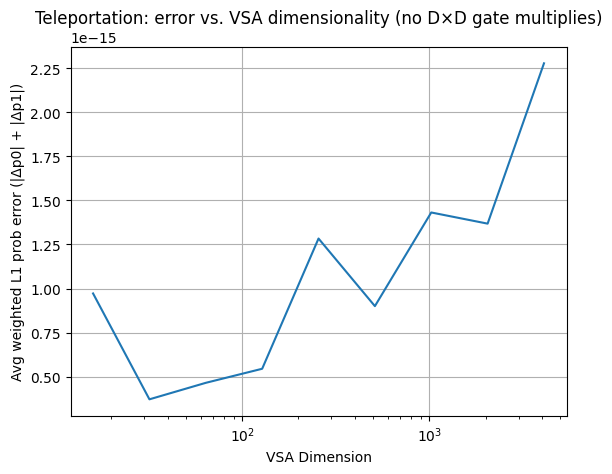

In [15]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- Cache helpers ----------
def prepare_vsa_codec_cache(QuantumVSAs):
    """
    Cache B (D,N) and B_pinv (N,D) for N = 2^n_qubits.
    Use complex128 internally for stability, then store complex128.
    """
    B128 = QuantumVSAs.basis_states.T.to(torch.complex128)   # (D,N)
    G = B128.conj().T @ B128                                 # (N,N)
    B_pinv128 = torch.linalg.solve(G, B128.conj().T)          # (N,D)

    QuantumVSAs._B = B128.to(torch.complex128)
    QuantumVSAs._B_pinv = B_pinv128.to(torch.complex128)
    QuantumVSAs._N = QuantumVSAs._B.shape[1]

def decode_coeffs(QuantumVSAs, phi):
    return QuantumVSAs._B_pinv @ phi.to(torch.complex128)      # (N,)

def encode_coeffs(QuantumVSAs, a):
    return QuantumVSAs._B @ a.to(torch.complex128)             # (D,)

def apply_U_to_phi(QuantumVSAs, U, phi):
    """
    Semantic gate action: phi <- B (U (B^+ phi))
    Does NOT build any D×D matrix.
    """
    a = decode_coeffs(QuantumVSAs, phi)                       # (N,)
    a = (U.to(a.device, a.dtype) @ a)                         # (N,)
    return encode_coeffs(QuantumVSAs, a)                      # (D,)

def build_teleportation_unitaries(device):
    dtype = torch.complex128
    I2 = torch.eye(2, dtype=dtype, device=device)

    H = (1.0 / math.sqrt(2.0)) * torch.tensor([[1, 1],[1, -1]], dtype=dtype, device=device)
    X = torch.tensor([[0, 1],[1, 0]], dtype=dtype, device=device)
    Z = torch.tensor([[1, 0],[0, -1]], dtype=dtype, device=device)

    # CNOT(0->1) on 2 qubits
    C = torch.zeros((4,4), dtype=dtype, device=device)
    for a in (0,1):
        for b in (0,1):
            in_idx = a*2 + b
            out_idx = a*2 + (b ^ a)
            C[out_idx, in_idx] = 1.0

    U_CNOT01 = torch.kron(C, I2)                 # (8,8)
    U_H0     = torch.kron(H, torch.kron(I2, I2)) # (8,8)
    U_X2     = torch.kron(torch.kron(I2, I2), X) # (8,8)
    U_Z2     = torch.kron(torch.kron(I2, I2), Z) # (8,8)
    return U_CNOT01, U_H0, U_X2, U_Z2


def teleportation_trial_abs_error(QuantumVSAs, alpha, beta, verbose=False):
    device = QuantumVSAs.basis_states.device
    s = len(QuantumVSAs.VSAs[0])

    # unitaries in coefficient space
    U_CNOT01, U_H0, U_X2, U_Z2 = build_teleportation_unitaries(device)

    # initial state in VSA space (as you had it)
    phi0 = (
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("000", s)] +
        alpha / math.sqrt(2) * QuantumVSAs.basis_states[int("011", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("100", s)] +
        beta  / math.sqrt(2) * QuantumVSAs.basis_states[int("111", s)]
    ).to(torch.complex128)

    # apply gates WITHOUT D×D matrices
    phi1 = apply_U_to_phi(QuantumVSAs, U_CNOT01, phi0)
    phi2 = apply_U_to_phi(QuantumVSAs, U_H0,     phi1)

    # decode full coefficient vector after measurement pre-steps
    a_pre = decode_coeffs(QuantumVSAs, phi2)  # (8,)

    results = {}
    for a_bit in (0,1):
        for b_bit in (0,1):
            i0 = int(f"{a_bit}{b_bit}0", s)
            i1 = int(f"{a_bit}{b_bit}1", s)

            c0, c1 = a_pre[i0], a_pre[i1]
            prob = float(((c0.conj()*c0 + c1.conj()*c1).real).item())

            if prob < 1e-12:
                results[(a_bit,b_bit)] = {"prob": prob, "abs_err": None}
                continue

            # post-measurement branch coefficients (only i0/i1 survive)
            a_post = torch.zeros_like(a_pre)
            norm_branch = math.sqrt(prob)
            a_post[i0] = c0 / norm_branch
            a_post[i1] = c1 / norm_branch

            # apply correction gates in coefficient space directly
            # (still via apply_U_to_phi, but you can also do a_post = U @ a_post)
            if b_bit == 1:
                a_post = U_X2 @ a_post
            if a_bit == 1:
                a_post = U_Z2 @ a_post

            # Bob amplitudes are exactly the (i0,i1) entries now
            d0, d1 = a_post[i0], a_post[i1]
            norm_bob = math.sqrt(float(((d0.conj()*d0 + d1.conj()*d1).real).item()))
            d0, d1 = d0/norm_bob, d1/norm_bob

            p0_vsa = float((d0.conj()*d0).real.item())
            p1_vsa = float((d1.conj()*d1).real.item())

            p0_true = float((alpha.conj()*alpha).real)
            p1_true = float((beta.conj()*beta).real)

            abs_err = float(abs(p0_vsa - p0_true) + abs(p1_vsa - p1_true))

            results[(a_bit,b_bit)] = {
                "prob": prob,
                "p_vsa": (p0_vsa, p1_vsa),
                "p_true": (p0_true, p1_true),
                "abs_err": abs_err,
            }
    return results


# ---------- Sweep ----------
verbose = False
n_trials = 50
VSA_dims = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
average_errors = []

for D in VSA_dims:
    QuantumVSAs = SymbolicEngineQuantumVSA(VSA_dim=D, n_qubits=3, n_states=2)
    prepare_vsa_codec_cache(QuantumVSAs)

    trial_errs = []
    for _ in range(n_trials):
        a, b = np.sqrt(np.random.uniform(0,1,2)) * np.exp(1.j*np.random.uniform(0,2*np.pi,2))
        norm = np.sqrt((a.conjugate()*a + b.conjugate()*b).real)
        a /= norm; b /= norm

        res = teleportation_trial_abs_error(QuantumVSAs, a, b, verbose=verbose)

        # probability-weighted average error
        num = den = 0.0
        for info in res.values():
            if info["abs_err"] is None:
                continue
            num += info["prob"] * info["abs_err"]
            den += info["prob"]
        trial_errs.append(num / max(den, 1e-12))

    average_errors.append(float(np.mean(trial_errs)))

plt.plot(VSA_dims, average_errors)
plt.xscale("log")
plt.xlabel("VSA Dimension")
plt.ylabel("Avg weighted L1 prob error (|Δp0| + |Δp1|)")
plt.title("Teleportation: error vs. VSA dimensionality (no D×D gate multiplies)")
plt.grid(True)
plt.show()


In [13]:
average_errors

[4.1714576914672093e-07,
 7.625648882367359e-07,
 5.749564902813109e-07,
 1.219310027993379e-06,
 7.610277263834025e-07,
 5.256027776597912e-07,
 1.0174375257915335e-06,
 8.800674723277431e-07,
 1.294096613761644e-06,
 1.4099939318302276e-06]

In [7]:
def metropolis_hastings_langevin(n_samples, x_t, mu, xi=0,  variance = 1e-3, epsilon=1e-2, cleanup=None, rule="Glad"):

    samples = [ np.copy(x_t) ] ## current sample point
    accepts = 0
    rejects = 0
    mu = mu.view(np.ndarray) # no longer a SSP ndarray, so that have to worry about * or ** doing something unexpected
    if rule=="Glad":
        def prob(x):
            return np.maximum(0, np.inner(x, mu) - xi)
        def dyn_step(x_t):
            p_x_t = prob(x_t)
            x_prime = x_t 
            if p_x_t > 0:
                x_prime += mu * float(epsilon / p_x_t)
            return x_prime 
    elif rule=="Born":
        if xi == 0:
            raise ValueError('bias term xi must be non-zero')
        ## get the probability of a sample point x using the born power rule
        def prob(x):
            return np.multiply(np.inner(x, mu)**2, xi)
        ## step to next sample (x_prime)
        def dyn_step(x_t):
            denom = np.inner(x_t, mu)
            dx = np.multiply(mu, 2*np.sign(denom)/np.maximum(1e-8,np.abs(denom)) )
            x_prime = x_t + epsilon*dx 
            return x_prime
    
    ## Sampling loop
    for i in range(n_samples):
        ## generate noise in ssp space
        ssp_noise = np.random.normal(loc=0, 
                                        scale=variance, 
                                        size=x_t.shape,
        )
        ## move to next sample point
        x_prime = dyn_step(x_t) + ssp_noise
        ## normalise
        
        #x_prime /= np.linalg.norm(x_prime)
        x_prime /= np.clip( np.linalg.norm(x_prime), a_min = 1e-16, a_max = None)

        ## Optional: clean up sample
        if cleanup is not None:
            x_prime = cleanup(x_prime)
        
        ## accept or reject sample
        alpha = prob(x_prime) / np.clip(prob(x_t),a_min =1e-16,a_max=None )
        #alpha = prob(x_prime) #/ np.clip(prob(x_t),a_min =1e-16,a_max=None 
        u = np.random.random()
        if u <= alpha:
            ## Accept: add new sample to list
            samples.append(np.copy(x_prime))
            x_t = x_prime
            accepts += 1
        else:
            ## Reject: go back to previous sample point
            samples.append(np.copy(x_t))
            rejects += 1
            
    return accepts,rejects,samples

